In [1]:
import pandas as pd

csv1 = pd.read_csv("data\crisp indices.csv", parse_dates=["QTDATE"])
csv2 = pd.read_csv("data\crisp treasury and inflation.csv", parse_dates=["caldt"])
csv3 = pd.read_csv("data\GDP.csv", parse_dates=["observation_date"])
csv4 = pd.read_csv("data\Interest rates.csv", parse_dates=["observation_date"])

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\G'
<>:6: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\G'
<>:6: SyntaxWarning: invalid escape sequence '\I'
C:\Users\manoj\AppData\Local\Temp\ipykernel_14856\762003149.py:3: SyntaxWarning: invalid escape sequence '\c'
  csv1 = pd.read_csv("data\crisp indices.csv", parse_dates=["QTDATE"])
C:\Users\manoj\AppData\Local\Temp\ipykernel_14856\762003149.py:4: SyntaxWarning: invalid escape sequence '\c'
  csv2 = pd.read_csv("data\crisp treasury and inflation.csv", parse_dates=["caldt"])
C:\Users\manoj\AppData\Local\Temp\ipykernel_14856\762003149.py:5: SyntaxWarning: invalid escape sequence '\G'
  csv3 = pd.read_csv("data\GDP.csv", parse_dates=["observation_date"])
C:\Users\manoj\AppData\Local\Temp\ipykernel

In [4]:

# Sort values (required for merge_asof)
csv1 = csv1.sort_values("QTDATE")
csv2 = csv2.sort_values("caldt")
csv3 = csv3.sort_values("observation_date")
csv4 = csv4.sort_values("observation_date")

# Base dataframe = quarterly dates from csv2
df = csv2.copy()

# Merge csv1 using nearest date
df = pd.merge_asof(
    df, csv1,
    left_on="caldt",
    right_on="QTDATE",
    direction="nearest"
)

# Merge csv3
df = pd.merge_asof(
    df, csv3,
    left_on="caldt",
    right_on="observation_date",
    direction="nearest"
)

# Merge csv4
df = pd.merge_asof(
    df, csv4,
    left_on="caldt",
    right_on="observation_date",
    direction="nearest"
)

# Rename final date column
df = df.rename(columns={"caldt": "date"})
df = df.drop(columns=["QTDATE", "observation_date_x", "observation_date_y"])
# Save result
df.to_csv("data/combined_quarterly_data.csv", index=False)

print(df.head())

        date    b30ret    b30ind    b20ret    b20ind    b10ret    b10ind  \
0 2014-03-31  0.086598  2188.225  0.069539  2685.825  0.036126  2189.678   
1 2014-06-30  0.047635  2292.460  0.039891  2792.964  0.025191  2244.837   
2 2014-09-30  0.040153  2384.509  0.030076  2876.966  0.007790  2262.325   
3 2014-12-31  0.097399  2616.757  0.087720  3129.332  0.028963  2327.849   
4 2015-03-31  0.052271  2753.538  0.030279  3224.086  0.024583  2385.075   

      b7ret     b7ind     b5ret  ...    t90ind    t30ret    t30ind    cpiret  \
0  0.017198  2355.010  0.008722  ...  968.7792  0.000085  794.7755  0.013920   
1  0.019310  2400.484  0.013131  ...  968.8994  0.000043  794.8097  0.008676   
2  0.002801  2407.207  0.000652  ...  969.0117  0.000020  794.8255 -0.001309   
3  0.022431  2461.202  0.014765  ...  969.0467  0.000016  794.8386 -0.013523   
4  0.023302  2518.553  0.019033  ...  969.1348 -0.000016  794.8259  0.005566   

   cpiind        CRSPID  DAYMAT  YLDMAT        GDP  IRLTLT01US

In [43]:
df.shape

(44, 26)

In [5]:
null_counts = df.isnull().sum()

print(null_counts)

date               0
b30ret             0
b30ind             0
b20ret             0
b20ind             0
b10ret             0
b10ind             0
b7ret              0
b7ind              0
b5ret              0
b5ind              0
b2ret              0
b2ind              0
b1ret              0
b1ind              0
t90ret             0
t90ind             0
t30ret             0
t30ind             0
cpiret             0
cpiind             0
CRSPID             0
DAYMAT             0
YLDMAT             0
GDP                0
IRLTLT01USQ156N    0
dtype: int64


In [31]:
from sklearn.pipeline import Pipeline

In [37]:
from xgboost import XGBRegressor 

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

In [27]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


def rf_cpiret_prediction(data, use_macro, model, test_quarters=4):

    macro_vars = ["CRSPID", "DAYMAT", "YLDMAT", "GDP", "IRLTLT01USQ156N"]

    df = data.copy()
    df = df.sort_values("date")
    dates = df["date"]

    X = df.drop(columns=["cpiret", "date"])
    y = df["cpiret"]

    # Remove macro variables as per choice
    if not use_macro:
        X = X.drop(columns=macro_vars, errors="ignore")

    # Train/Test split
    X_train = X.iloc[:-test_quarters]
    X_test = X.iloc[-test_quarters:]

    y_train = y.iloc[:-test_quarters]
    y_test = y.iloc[-test_quarters:]

    test_dates = dates.iloc[-test_quarters:]

    if model == 'RF':
        model = RandomForestRegressor(
            n_estimators=500,
            random_state=42
        )
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    elif model == 'GB':
        model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
        )
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    elif model == 'XGB':
        model = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective='reg:squarederror'
        )

        model.fit(X_train, y_train)
        predictions = model.predict(X_test) 

    # Metrics
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results = pd.DataFrame({
        "date": test_dates.values,
        "actual_cpiret": y_test.values,
        "predicted_cpiret": predictions
    })

    x = range(len(results))
    plt.figure(figsize=(7,4))
    plt.plot(x, results["actual_cpiret"], marker="o", label="Actual")
    plt.plot(x, results["predicted_cpiret"], marker="o", label="Predicted")

    plt.xticks(x, results["date"].dt.strftime('%Y-%m-%d'))
    plt.xlabel("Quarter")
    plt.ylabel("cpiret")

    title = "RF CPI Prediction (With Macro)" if use_macro else "RF CPI Prediction (Without Macro)"
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results, mse, r2

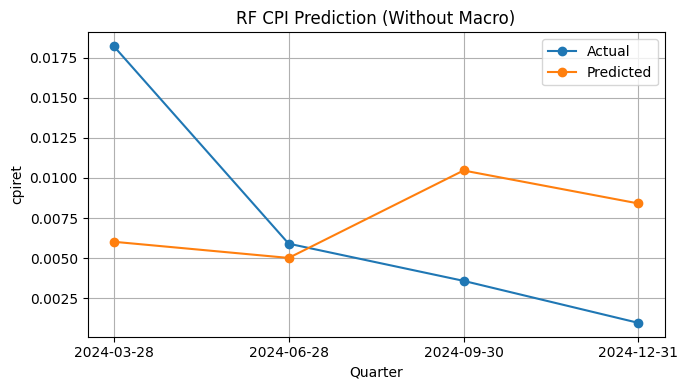

        date  actual_cpiret  predicted_cpiret
0 2024-03-28       0.018211          0.006020
1 2024-06-28       0.005901          0.005012
2 2024-09-30       0.003584          0.010462
3 2024-12-31       0.000964          0.008407
MSE: 6.302908191964065e-05
R2: -0.44158920839465066


In [41]:
results_no_macro, mse_no_macro, r2_no_macro = rf_cpiret_prediction(df, use_macro=False, model='XGB')

print(results_no_macro)
print("MSE:", mse_no_macro)
print("R2:", r2_no_macro)

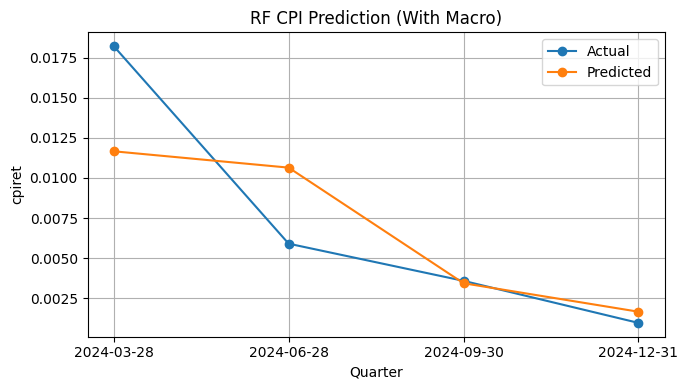

        date  actual_cpiret  predicted_cpiret
0 2024-03-28       0.018211          0.011659
1 2024-06-28       0.005901          0.010641
2 2024-09-30       0.003584          0.003435
3 2024-12-31       0.000964          0.001660
MSE: 1.6475718325889575e-05
R2: 0.6231704950195187


In [42]:
results_macro, mse_macro, r2_macro = rf_cpiret_prediction(df, use_macro=True, model='XGB')

print(results_macro)
print("MSE:", mse_macro)
print("R2:", r2_macro)